In [1]:
import random
mean = 0.0
stddev = 0.1
def generate_normal_weights_matrix(rows, cols, mean=0.0, stddev=0.1):
    return [[random.gauss(mean, stddev) for _ in range(cols)] for _ in range(rows)]

weights_matrix = generate_normal_weights_matrix(5, 5)
for row in weights_matrix:
    print(row)


[-0.15600233097595434, -0.18648969839334642, 0.03366681149118671, -0.13165439727447723, -0.017268458970081835]
[0.2591424695172595, 0.09675404622132593, -0.021912082954057263, -0.14142847306757145, -0.04979977249235361]
[0.10394858846485203, -0.05120249092100171, -0.03423835297488997, 0.004702155972259536, 0.12366323785711926]
[-0.18851895965546925, 0.07444818063776174, 0.06329132604955527, 0.12552923927053158, -0.25386595316169774]
[-0.041887370732128976, 0.0789435410510404, -0.17921837970072693, -0.1895512764456582, 0.15475878220019879]


In [2]:
weights_matrix = generate_normal_weights_matrix(100, 100, mean, stddev)
weights = [weight for row in weights_matrix for weight in row]

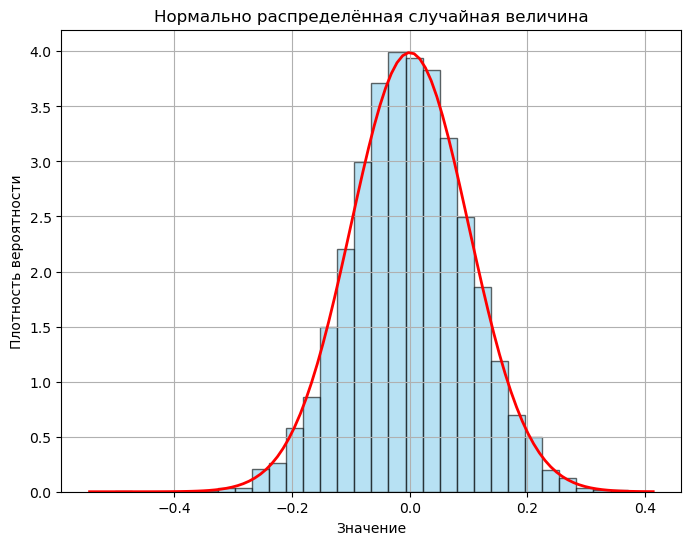

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats
plt.figure(figsize=(8, 6))
count, bins, ignored = plt.hist(weights, bins=30, density=True, alpha=0.6, color='skyblue', edgecolor='black')

xmin, xmax = plt.xlim()
x = np.linspace(xmin, xmax, 100)
p = stats.norm.pdf(x, mean, stddev)  
plt.plot(x, p, 'r', linewidth=2)

plt.title("Нормально распределённая случайная величина")
plt.xlabel("Значение")
plt.ylabel("Плотность вероятности")
plt.grid(True)

plt.show()

In [4]:
min_value = min(weights)
max_value = max(weights)

print(f"Минимальное значение: {min_value}")
print(f"Максимальное значение: {max_value}")

Минимальное значение: -0.5005725484410996
Максимальное значение: 0.3701903883587604


In [5]:
num_levels = 256  
step = (max_value - min_value) / (num_levels - 1)
print(f"Шаг квантизации: {step}")

Шаг квантизации: 0.0034147566149014116


In [6]:
quantized_weights = [round((weight - min_value) / step) for weight in weights]

print("Квантизированные веса:")
print(set(quantized_weights))

Квантизированные веса:
{0, 43, 53, 54, 55, 56, 57, 59, 60, 62, 63, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99, 100, 101, 102, 103, 104, 105, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115, 116, 117, 118, 119, 120, 121, 122, 123, 124, 125, 126, 127, 128, 129, 130, 131, 132, 133, 134, 135, 136, 137, 138, 139, 140, 141, 142, 143, 144, 145, 146, 147, 148, 149, 150, 151, 152, 153, 154, 155, 156, 157, 158, 159, 160, 161, 162, 163, 164, 165, 166, 167, 168, 169, 170, 171, 172, 173, 174, 175, 176, 177, 178, 179, 180, 181, 182, 183, 184, 185, 186, 187, 188, 189, 190, 191, 192, 193, 194, 195, 196, 197, 198, 199, 200, 201, 202, 203, 204, 205, 206, 207, 208, 209, 210, 211, 212, 213, 214, 215, 216, 217, 218, 219, 220, 221, 222, 223, 224, 225, 226, 227, 228, 229, 230, 234, 239, 240, 241, 243, 247, 249, 251, 255}


In [7]:
recovered_weights = [quantized_weight * step + min_value for quantized_weight in quantized_weights]

print("Восстановленные веса:")
print(recovered_weights[:5])

Восстановленные веса:
[0.09359510255174608, -0.05323943188901464, 0.1243279120858588, 0.06286229301763335, -0.07031321496352166]


In [8]:
max([abs(w - rw) for w, rw in zip(weights, recovered_weights)])

0.0017067683497665048

In [9]:
def quantize_weights(weights, max_error):
    min_value = min(weights)
    max_value = max(weights)
    num_levels = 256
    step = (max_value - min_value) / (num_levels - 1)
    
    quantized_weights = [round((weight - min_value) / step) for weight in weights]
    return quantized_weights, step, min_value

def dequantize_weights(quantized_weights, step, min_value):
    return [q * step + min_value for q in quantized_weights]

max_error = 0.01
quantized_weights, step, min_value = quantize_weights(weights, max_error)
recovered_weights = dequantize_weights(quantized_weights, step, min_value)

In [10]:
from collections import Counter, namedtuple
import heapq

class Node(namedtuple("Node", ["freq", "char", "left", "right"])):
    def __lt__(self, other):
        return self.freq < other.freq

def huffman_tree(freq_dict):
    heap = [Node(freq, char, None, None) for char, freq in freq_dict.items()]
    heapq.heapify(heap)
    
    while len(heap) > 1:
        left = heapq.heappop(heap)
        right = heapq.heappop(heap)
        node = Node(left.freq + right.freq, None, left, right)
        heapq.heappush(heap, node)
    
    return heap[0]

def huffman_codes(node, prefix=""):
    if node.char is not None:
        return {node.char: prefix}
    result = {}
    result.update(huffman_codes(node.left, prefix + "0"))
    result.update(huffman_codes(node.right, prefix + "1"))
    return result

def huffman_encode(data):
    freq_dict = Counter(data)
    tree = huffman_tree(freq_dict)
    huff_dict = huffman_codes(tree)
    encoded_data = ''.join(huff_dict[char] for char in data)
    return encoded_data, huff_dict

def huffman_decode(encoded_data, huff_dict):
    reverse_dict = {v: k for k, v in huff_dict.items()}
    decoded_data = []
    buffer = ""
    for bit in encoded_data:
        buffer += bit
        if buffer in reverse_dict:
            decoded_data.append(reverse_dict[buffer])
            buffer = ""
    return decoded_data

data = "ABRACADABRA"
encoded_data, huff_dict = huffman_encode(data)
decoded_data = huffman_decode(encoded_data, huff_dict)

In [11]:
def bit_packing(bit_string):
    packed_data = bytearray()
    for i in range(0, len(bit_string), 8):
        byte = bit_string[i:i + 8]
        packed_data.append(int(byte, 2))
    return bytes(packed_data)

def bit_unpacking(packed_data):
    return ''.join(f"{byte:08b}" for byte in packed_data)

encoded_bit_string = "0110110011001"  
packed_data = bit_packing(encoded_bit_string)
unpacked_data = bit_unpacking(packed_data)

In [12]:
with open('output.bin', 'wb') as f:
    f.write(f"{step:.6f}\n".encode())

In [13]:
with open('output.bin', 'rb') as f:
    step = float(f.readline().strip())
    print(step)

0.003415


In [14]:
def write_to_file(data, filename):
    with open(filename, 'wb') as file:
        file.write(data)

In [15]:
compresed_filename = 'compressed_data.bin'

In [16]:
def read_from_file(filename):
    with open(filename, 'rb') as file:
        return file.read()

filename = "compressed_data.bin"
write_to_file(packed_data, filename)
read_data = read_from_file(filename)